SMOTE (SYNTHETIC MINORITY OVERSAMPLING TECHNIQUE)


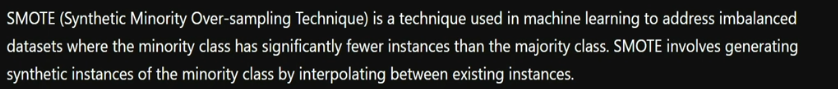

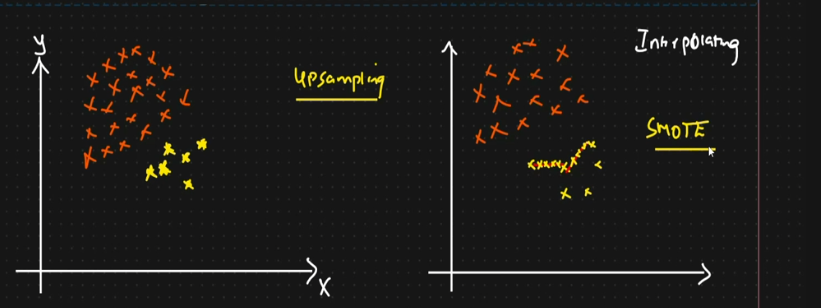

in upsmapling we are adding more data points over the existing data (duplicates).
in smote we consider two nearest points in our dataset and add extra data between these points. 

### Quick Summary

#### 1. Column

A vertical field in a dataset.

Example:

| Age | Salary | Class |
| --- | ------ | ----- |

Here there are **3 columns**.

---

#### 2. Feature

An **input column** used to predict something.

| Age     | Salary  | Class  |
| ------- | ------- | ------ |
| Feature | Feature | Target |

So:

```text
Features = Age, Salary
```

In `make_classification`:

```python
n_features = number of feature columns
```

---

#### 3. Class

The **label/category** we want to predict.

Examples:

* Spam / Not Spam
* Cat / Dog / Bird
* 0 / 1 / 2

In `make_classification`:

```python
n_classes = number of possible labels
```

---

#### 4. Class Column (Target Column)

| Age | Salary | Class |
| --- | ------ | ----- |
| 25  | 50000  | 0     |
| 40  | 120000 | 1     |

`Class` is a **column**, but it is **not a feature**.

---

#### 5. `n_clusters_per_class`

A class can have multiple groups (clusters).

```text
Class 0
 ├─ Cluster A
 └─ Cluster B

Class 1
 ├─ Cluster C
 └─ Cluster D
```

```python
n_clusters_per_class = 2
```

means each class is split into 2 clusters.

---

### One-line Mental Model

```text
Dataset
├── Feature Columns (X)
│   ├── Feature 1
│   ├── Feature 2
│   └── ...
└── Class/Target Column (y)
     ├── Class 0
     ├── Class 1
     └── ...
```

**Columns ⊇ Features + Target Column**
**Classes are values inside the target column.**


In [13]:
from sklearn.datasets import make_classification

In [14]:
X,y = make_classification(n_samples=1000,n_features=2,n_clusters_per_class=1,
                    weights = [0.9],random_state=12,n_redundant=0)

## x is independent feature and y is a dependent feature

In [15]:
import pandas as pd
df1 = pd.DataFrame(X,columns=['f1','f2'])
df2 = pd.DataFrame(y,columns=['target'])


In [19]:
final_df = pd.concat([df1,df2],axis = 1)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [20]:
final_df['target'].value_counts()
print(final_df)

           f1        f2  target
0   -0.762898 -0.706808       0
1   -1.075436 -1.051162       0
2   -0.610115 -0.909802       0
3   -2.023284 -0.428945       1
4   -0.812921 -1.316206       0
..        ...       ...     ...
995 -0.712495 -0.880452       0
996 -2.625830 -2.827891       0
997 -1.326439 -1.815178       0
998 -0.833486 -0.514647       0
999 -0.302876 -0.575975       0

[1000 rows x 3 columns]


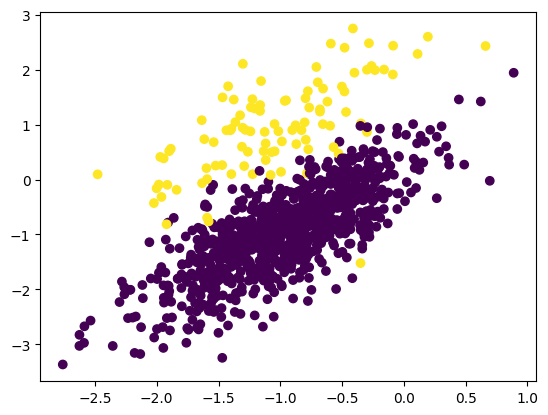

In [21]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])

In [22]:
##  to work with smote we need to install a library named imblearn

!pip install imblearn


   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   -------------------------- ------------- 2/3 [imblearn]
   ---------------------------------------- 3/3 [imblearn]



In [23]:
from imblearn.over_sampling import SMOTE



In [24]:
## transform the dataset
oversample = SMOTE()
X,y = oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [26]:
X.shape

(1800, 2)

In [27]:
y.shape

(1800,)

In [28]:
y==0

0        True
1        True
2        True
3       False
4        True
        ...  
1795    False
1796    False
1797    False
1798    False
1799    False
Name: target, Length: 1800, dtype: bool

In [29]:
len(y[y==0])

900

In [30]:
len(y[y==1])

900

In [31]:
df1 = pd.DataFrame(X,columns=['f1','f2'])
df2 = pd.DataFrame(y,columns=['target'])
oversample_df = pd.concat([df1,df2],axis = 1)

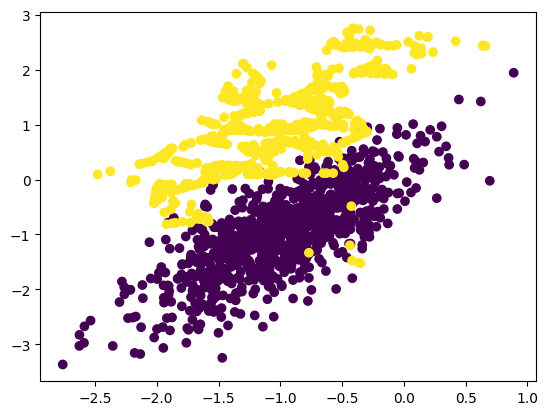

In [32]:
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])